#### 逻辑回归表达式
$$y=\frac{1}{1+e^{-\theta}}$$
$$\theta=WX + B$$

> y表示概率，即为坏人的概率

**导入需要的包**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import os

**加载数据**

In [4]:
file = 'testSet.txt'
if os.path.exists(file):
    data = np.loadtxt(file)
features = data[:, :2]   # 取前两列作为特征 features
labels = data[:, -1]     # 取最后一列作为标签 labels

print(features.shape, labels.shape)

(100, 2) (100,)


In [5]:
print('特征的维度: {0}'.format(features.shape[1]))
print('总共有{0}个类别'.format(len(np.unique(labels))))  # label可能表示为好人/坏人，故有两个类别

特征的维度: 2
总共有2个类别


**可视化数据¶**

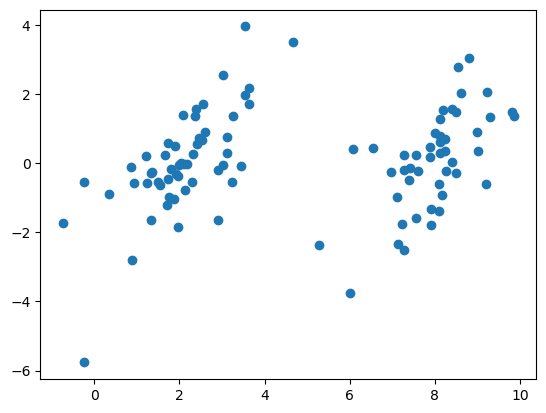

In [6]:
figure = plt.figure()
# 用第一列、第二列特征分别作为 x、y 轴绘制散点图
plt.scatter([x[0] for x in features], [x[1] for x in features])
plt.show()

**实现sigmoid函数**
$$𝑠𝑖𝑔𝑚𝑜𝑖𝑑(x) = \frac{1}{1 + e^{-x}}$$

In [7]:
def sigmoid(x):
    return  1 / (1 + np.exp(-x))

print(sigmoid(-5), sigmoid(5))  # 对sigmoid函数进行测试

0.0066928509242848554 0.9933071490757153


**sigmoid函数的导数**
$$\delta𝑠𝑖𝑔𝑚𝑜𝑖𝑑(𝑥)=\delta\frac{1}{1+e^{-x}}=\delta\frac{e^{-x}}{(1+e^{-x})^{2}}=\delta\frac{1}{1+e^{-x}}*\frac{e^{-x}}{1+e^{-x}}=𝑠𝑖𝑔𝑚𝑜𝑖𝑑(𝑥)*\frac{1+e^{-x}-1}{1+e^{-x}}=𝑠𝑖𝑔𝑚𝑜𝑖𝑑(𝑥)*(1-𝑠𝑖𝑔𝑚𝑜𝑖𝑑(𝑥))$$

In [8]:
def delta_sigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))

delta_sigmoid(5)

np.float64(0.006648056670790033)

#### 基础建模

**随机初始化权重, 从正态分布中生成**

In [9]:
# 随机初始化权重矩阵 W，形状为 (1, 特征数)，服从 [0,1) 均匀分布
W = np.random.uniform(size=(1, features.shape[1])) # 形状为一行、列数等于特征数
W
# 查看W的数据类型
print(W)
# 查看W的形状
print(W.shape)

[[0.76651525 0.97665322]]
(1, 2)


**矩阵乘法**

In [10]:
def matrix_mul(matrix1, matrix2):
    # 计算并返回 matrix1 与 matrix2 的矩阵乘法结果
    # matrix1 的行数必须等于 matrix2 的列数
    # matrix1 的列数必须等于 matrix2 的行数
    # 如果 matrix1 的形状为 (m, n)，matrix2 的形状为 (n, p)，则矩阵乘法的结果为 (m, p)
    return np.matmul(matrix1, matrix2)

print(matrix_mul(np.random.uniform(size=(1, 2)), np.random.uniform(size=(2, 1))))

[[0.78905067]]


**矩阵求导**
$$Result_{ij} = \sum_{j}W_{i,j}*\sum_{i}X_{i,j}$$
$$\frac{\delta Result_{ij}}{\delta W_{ij} = \sum_{j \in J}X_{j}}$$
$$\delta W = \sum X^{T}*Weights^{T}(按权求和)$$

In [11]:
def delta_matrix(X, W):
    # np.ones(shape=(len(X), 1)) 生成一个形状为 (len(X), 1) 的矩阵，矩阵中的元素都为 1
    # np.matmul(X.T, np.ones(shape=(len(X), 1))) 计算 X 的转置与 1 的矩阵乘法
    # .T 表示矩阵的转置
    # len(X) 表示 X 的行数
    # 最后将结果除以 len(X) 得到平均值
    return np.matmul(X.T, np.ones(shape=(len(X), 1))).T / len(X)

W = np.random.uniform(low=0, high=1, size=(1, 2))
X = np.random.uniform(low=3, high=15, size=(3, 2))
delta = delta_matrix(X, W)
print(delta, W - delta)

[[ 8.90413383 11.44608883]] [[ -8.69245769 -10.50795518]]


**包含偏置项**

In [12]:
def add_bias(result, B):
#     assert len(result) == len(B)
    return result + B

B = np.random.uniform(size=(1,))
print(B, add_bias(matrix_mul(W, X.T), B))

[0.95375366] [[11.32597378 15.15206032 14.25148807]]


**对偏置项求导**
$$y_{p} = WX + B$$
$$\delta\frac{y_{p}}{B} = \frac{\sum_{i}^{n}1}{n}$$

In [13]:
def delta_B():
    return 1

delta_B()

1

**完整的逻辑回归 inference**

In [14]:
def logic(W, X, B):
    mul = matrix_mul(W, X)
    y = add_bias(mul, B)
    return y

logic(W, X.T, B)

array([[11.32597378, 15.15206032, 14.25148807]])

**损失函数(Cross-entropy, 交叉熵损失函数)**  
`信息熵`: -PlogP(P是概率, 小于1, 取反之后就是正数了), 这个值代表的是信息量, 如果值越大代表对当前情况越不确定, 信息不足.
$$loss = -\sum y_{t}logy_{p} + (1-y_{t})log(1-y_{p})$$
$y_{t}$: 真实的Y值, 需要进行独热编码  
$y_{p}$: 预测的Y值  

In [15]:
def loss(Y_t, Y_p):
    '''
        算交叉熵损失函数
        Y_t: 独热编码之后的真实值向量
        Y_p: 预测的值向量        
    '''
    trans = np.zeros(shape=Y_t.shape)
    for sample_idx in range(len(trans)):
        # print(trans[sample_idx], [Y_p[sample_idx], 1.0 - Y_p[sample_idx]])
        # 避免出现0
        trans[sample_idx] = [Y_p[0][sample_idx] , 1.0 - Y_p[0][sample_idx] + 1e-5]
    log_y_p = np.log(trans)
    return -np.sum(np.multiply(Y_t, log_y_p))

Y_t = np.array([[0, 1], [1, 0]])
Y_p = np.array([[0.8, 1]])

loss(Y_t=Y_t, Y_p=Y_p)

np.float64(1.609387913684059)

**交叉熵求导**  
$$\frac{\delta loss}{\delta Y_{p}} = \frac{\delta Y_{t}logY_{p}}{\delta Y_{p}} = \sum_{n}^{N} - \frac{Y_{i}}{P_{i}} + \frac{1-Y_{i}}{1-P_{i}}$$

In [17]:
def delta_cross_entropy(Y_t, Y_p):
    trans = np.zeros(shape=Y_t.shape)
    for sample_idx in range(len(trans)):
        trans[sample_idx] = [Y_p[0][sample_idx] + 1e-8, 1.0 - Y_p[0][sample_idx] + 1e-8]
    
    Y_t[Y_t == 0] += 1e-8
    error = Y_t * (1 / trans)
    error[:, 0] = -error[:, 0]
    return np.sum(error, axis=1, keepdims=True)

Y_t = np.array([[0, 1], [1, 0]], dtype=np.float64)
Y_p = np.array([[0.8, 1]])
delta_cross_entropy(Y_t=Y_t, Y_p=Y_p)

array([[4.99999974e+00],
       [9.99999983e-09]])

In [18]:
def accuracy(Y_p, Y_t):
    Y_p[Y_p >= 0.5] = 1
    Y_p[Y_p < 0.5] = 0
    predict = np.sum(Y_p == Y_t)
    return predict /  len(Y_t)

**准确率计算**  
`混淆矩阵`  

<div align='center'>  

|T\Pre|Positive|Negative|  
|:---:|:---:|:---:|  
|Positive|TP|FN|  
|Negative|FP|TN|  

</div>

**评估指标**  
`召回率计算`  
$$recall = \frac{TP}{TP + FP}$$  

`精准率计算`  
$$precision = \frac{TP}{TP + FN}$$  

In [19]:
def recall(Y_p, Y_t):
    return np.sum(np.argmax(Y_p) == np.argmax(Y_t)) / np.sum(Y_p == 1)

**独热编码**  
如果有两个类别  

<div align='center'>  

|类别|独热编码|  
|:---:|:---:|  
|0|[1, 0]|  
|1|[0, 1]|  

</div>  

In [20]:
def one_hot(y):
    classes = np.arange(len(np.unique(y)))
    one_hot_label = np.zeros(shape=(len(y), len(classes)))
    for sample in range(len(y)):
        one_hot_label[sample][classes == y[sample]] = 1
    return one_hot_label

one_hot([0, 1, 2, 3])

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

**更新权重**  
$$W = W - \varphi\delta W = W - \frac{\delta loss}{\delta W}$$

In [21]:
def update_parameters(Y_t, W, B, X, learning_rate=0.1):
#     mul = matrix_mul(W, X)
#     Y_p = add_bias(mul, B)
    Y_p = np.matmul(W, X.T)
    Y_p += B
    Y_p = sigmoid(Y_p)
    error = loss(one_hot(Y_t), Y_p)
    # 里面是按列计算的, 进行了转换, 所以这里也需要转置
#     delta_loss = delta_cross_entropy(one_hot(Y_t), Y_p)
    
#     delta_activation = delta_sigmoid(Y_p)
#     derror = np.multiply(delta_loss, delta_activation)
#     dw = np.matmul(derror, X)
    # 误差项
    error_rate = Y_p - Y_t
    deltaW = np.matmul(error_rate, X) / len(Y_t)
    deltaB = error_rate * delta_B()
    deltaB = np.sum(deltaB) / len(X)
    W -= (learning_rate * deltaW)
    B -= (learning_rate * deltaB)
    return error, W, B

np.random.seed(1)
W = np.random.uniform(size=(1, 2))
print(W)
X = np.random.uniform(size=(3, 2))
Y_t = np.array([1, 0, 1])
update_parameters(Y_t, W, B, X)

[[0.417022   0.72032449]]


(np.float64(3.2590147582402897),
 array([[0.41472014, 0.72291528]]),
 array([0.94399665]))

**归一化特征数据并且可视化**  

In [22]:
import copy

def normalize(x, mean, max_value, min_value, is_normalize=False):
    f = copy.deepcopy(x)
    f -= mean
    if is_normalize:
        f = (f - min_value) / (max_value - min_value)
    return f

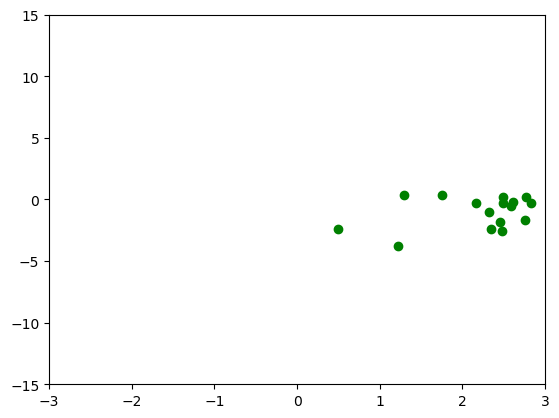

In [23]:
mean = np.mean(features, axis=0)
max_value = np.max(features, axis=0)
min_value = np.min(features, axis=0)

f_normalize_features = normalize(features, mean, max_value, min_value)

figure = plt.figure()
plt.scatter([x[0] for x in f_normalize_features[labels == 0]], [x[1] for x in f_normalize_features[labels == 0]], c='r')
plt.scatter([x[0] for x in f_normalize_features[labels == 1]], [x[1] for x in f_normalize_features[labels == 1]], c='g')
plt.xlim(left=-3, right=3)
plt.ylim(bottom=-15, top=15)
plt.show()

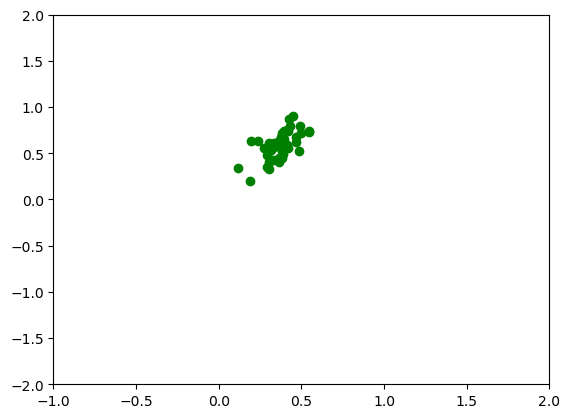

In [24]:
mean = np.mean(features, axis=0)
max_value = np.max(features, axis=0)
min_value = np.min(features, axis=0)

f_normalize_features = normalize(features, mean, max_value, min_value, is_normalize=True)

figure = plt.figure()
plt.scatter([x[0] for x in f_normalize_features[labels == 0]], [x[1] for x in f_normalize_features[labels == 0]], c='r')
plt.scatter([x[0] for x in f_normalize_features[labels == 1]], [x[1] for x in f_normalize_features[labels == 1]], c='g')
plt.xlim(left=-1, right=2)
plt.ylim(bottom=-2, top=2)
plt.show()

**拆分数据集**  
分为`训练集`和`测试集`, 占比为0.7:0.3  

In [25]:
test_size = int(len(labels) * 0.3)
random_idx = np.random.permutation(len(labels))
test_features = features[random_idx[:test_size]]
test_labels = labels[random_idx[:test_size]]
train_features = features[random_idx[test_size:]]
train_labels = labels[random_idx[test_size:]]

print('test_features type{0}'.format(test_features.shape))
print('train_features type{0}'.format(train_features.shape))

test_features type(30, 2)
train_features type(70, 2)


**推理加训练**  

In [26]:
def drawLine(weights, B=0):
    dataArr = features
    n = np.shape(dataArr)[0] 
    xcord1 = []; ycord1 = []
    xcord2 = []; ycord2 = []
    for i in range(n):
        if int(labels[i])== 1:
            xcord1.append(dataArr[i,0]); ycord1.append(dataArr[i,1])
        else:
            xcord2.append(dataArr[i,0]); ycord2.append(dataArr[i,1])
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(xcord1, ycord1, s=30, c='red', marker='s')
    ax.scatter(xcord2, ycord2, s=30, c='green')
    x = np.arange(-3.0, 3.0, 0.1)
    y = (-B-weights[0][1]*x-1) / weights[0][1]
    ax.plot(x, y)
    plt.xlabel('X1'); plt.ylabel('X2');
    plt.show()

Update W: [[0.1653542  0.92750858]]
epoch 1: train_loss:3.5901889988544715


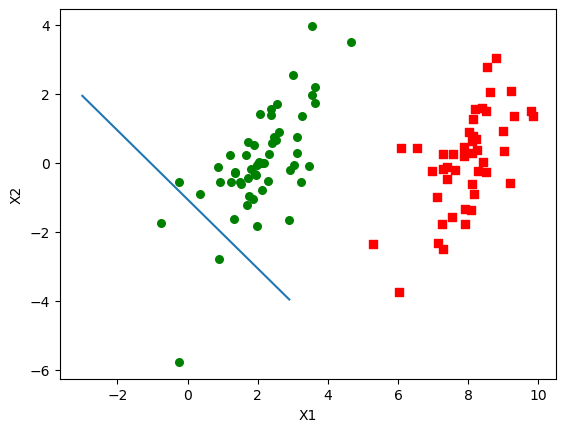

Update W: [[0.12096409 0.91771959]]
epoch 2: train_loss:3.028097097429325


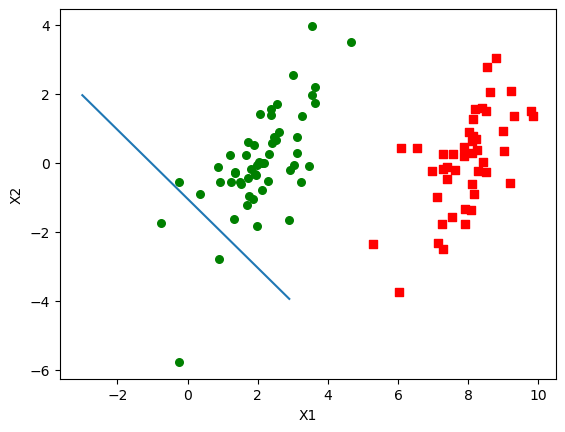

Update W: [[0.08389595 0.90792889]]
epoch 3: train_loss:2.5839043263984918


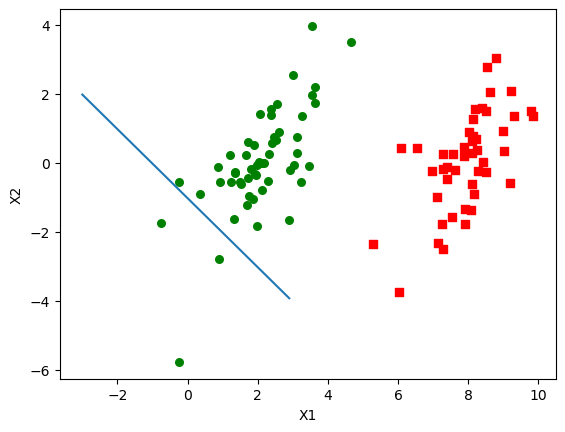

Update W: [[0.05395437 0.89826046]]
epoch 4: train_loss:2.242938991529929


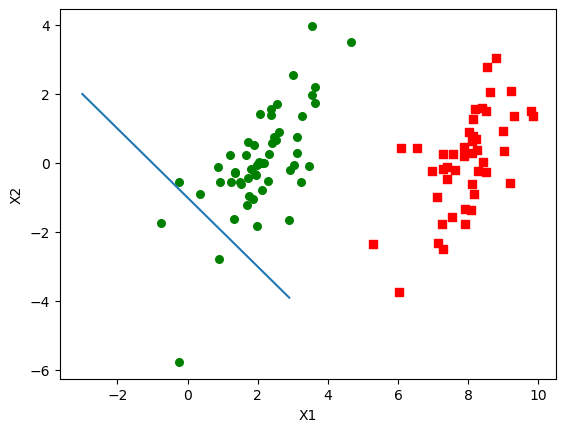

Update W: [[0.03049516 0.88879514]]
epoch 5: train_loss:1.986267610833115


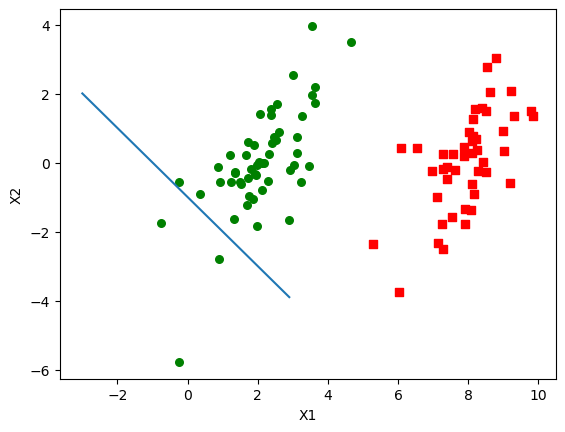

Update W: [[0.01261945 0.87957036]]
epoch 6: train_loss:1.795079204401633


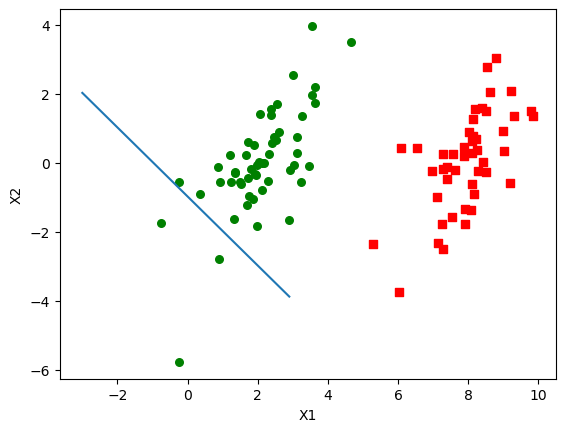

Update W: [[-6.34330295e-04  8.70590564e-01]]
epoch 7: train_loss:1.653231156205726


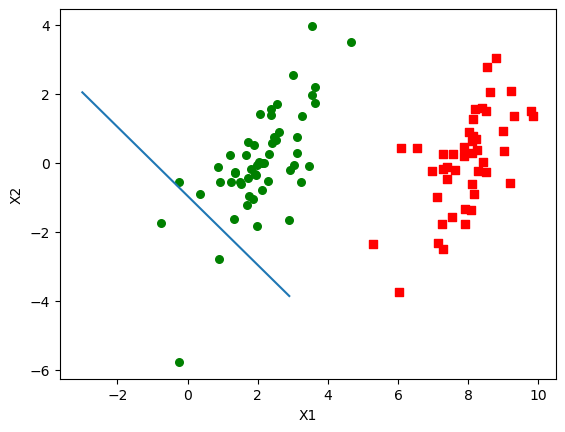

Update W: [[-0.010164    0.86184036]]
epoch 8: train_loss:1.547996865291415


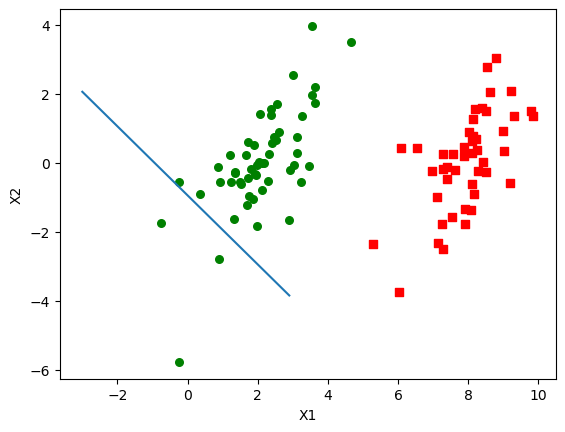

Update W: [[-0.01674503  0.85329518]]
epoch 9: train_loss:1.4697982639641962


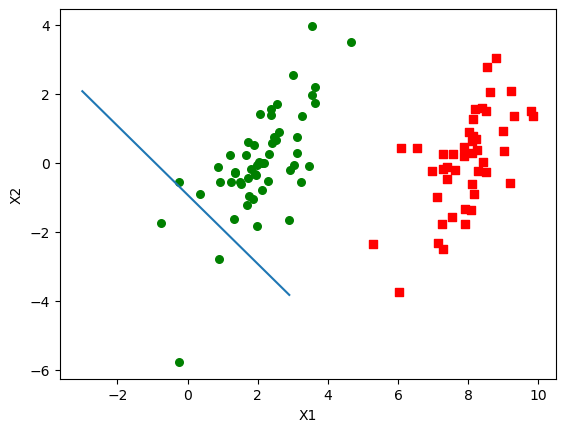

Update W: [[-0.02101711  0.84492819]]
epoch 10: train_loss:1.4115864082824974


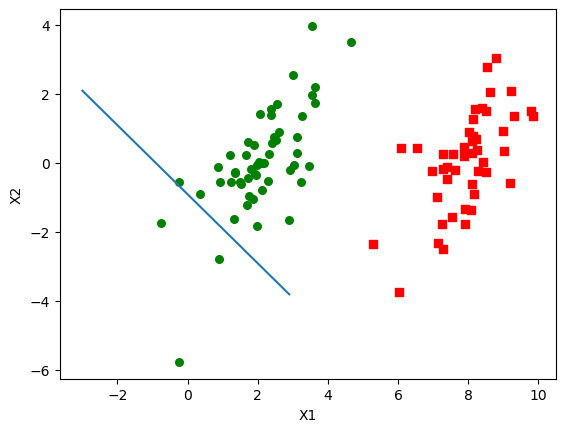

Update W: [[-0.02349378  0.83671402]]
epoch 11: train_loss:1.3682139083419376


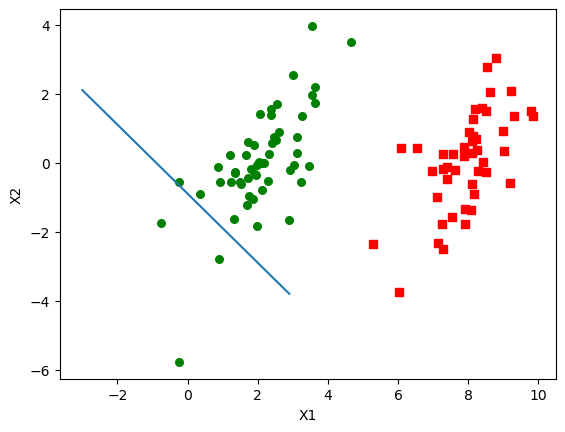

Update W: [[-0.02458067  0.82863039]]
epoch 12: train_loss:1.3359199587510686


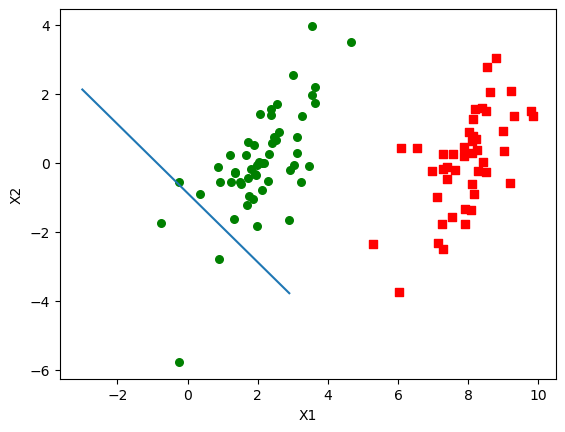

Update W: [[-0.02459512  0.82065861]]
epoch 13: train_loss:1.311943533123618


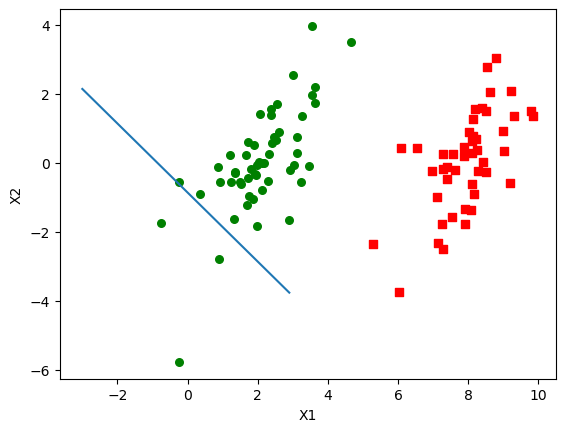

Update W: [[-0.02378399  0.81278343]]
epoch 14: train_loss:1.2942441155582323


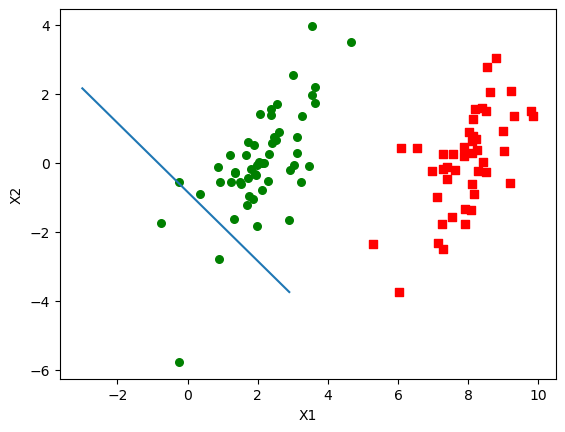

Update W: [[-0.02233864  0.80499265]]
epoch 15: train_loss:1.2813031253477085


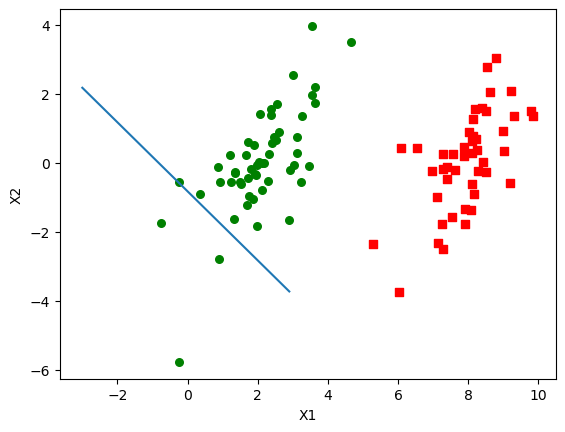

(array([[-0.02040706,  0.79727665]]), np.float64(-0.3417264143577606))

In [27]:
def train(train_features, test_features, train_labels, test_labels, epoch=15, learning_rate=0.008):
    W = np.random.uniform(size=(1, train_features.shape[1]))
    B = 0
    for current in range(epoch):
        np.random.seed(current)
        random_train_features_idx = np.random.choice(np.arange(len(train_features)), size=(16,))
        random_train_features = train_features[random_train_features_idx]
        random_train_labels = train_labels[random_train_features_idx]
        print('Update W:', W)
        Y_p = np.matmul(W, train_features.T)
        Y_p += B
        Y_p = sigmoid(Y_p)
        error = loss(one_hot(train_labels), Y_p) / len(random_train_features)
        # 误差项
        error_rate = Y_p - train_labels
        deltaW = np.matmul(error_rate, train_features) / len(random_train_labels)
        deltaB = error_rate * delta_B()
        deltaB = np.sum(deltaB) / len(random_train_labels)
        W -= (learning_rate * deltaW)
        B -= (learning_rate * deltaB)
        print('epoch {0}: train_loss:{1}'.format(current + 1, error))
        drawLine(W, B)
    return W, B
train(train_features, test_features, train_labels, test_labels)